# Lexicon-Based Sentiment Analysis — Bluesky US Election 2024

## 0 : Setup

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from house_style import *
apply_style()

PURPLE = '#9b5de5'  # extra colour not in house_style

BUZZ_COLORS = {'TrumpBuzz': REPUBLICAN, 'HarrisBuzz': DEMOCRAT, 'ElectionBuzz': NEUTRAL}

# ── Event markers ────────────────────────────────────────────────────────────
EVENTS = [
    {'label': 'Trump Shot',      'date': pd.Timestamp('2024-07-13'), 'color': REPUBLICAN},
    {'label': 'Biden Drops Out', 'date': pd.Timestamp('2024-07-21'), 'color': DEMOCRAT},
    {'label': 'Debate',          'date': pd.Timestamp('2024-09-10'), 'color': ACCENT},
    {'label': 'Golf Attempt',    'date': pd.Timestamp('2024-09-15'), 'color': PURPLE},
]

print('Setup complete.')

Setup complete.


In [6]:
# os.chdir(r'C:\Users\Ddhuy\OneDrive - UGent\DocumentenUGentMaster\SocialMediaAndWebAnalysis\group-project-SMWA')

In [7]:
df_clean = pd.read_csv("Data/2_Silver/Bluesky/cleaned_data.csv", parse_dates=['date'])
df_clean['date'] = pd.to_datetime(df_clean['date']).dt.normalize()
df_clean['text_norm'] = df_clean['text_norm'].fillna('')
df_clean['text']      = df_clean['text'].fillna('')

# Recreate buzz_group if missing
if 'buzz_group' not in df_clean.columns:
    def assign_buzz(t):
        t = str(t).lower()
        if 'trump'  in t: return 'TrumpBuzz'
        if 'harris' in t: return 'HarrisBuzz'
        return 'ElectionBuzz'
    df_clean['buzz_group'] = df_clean['text_norm'].apply(assign_buzz)

print(f"Loaded {len(df_clean):,} rows  |  {df_clean['date'].min().date()} → {df_clean['date'].max().date()}")
print(df_clean['buzz_group'].value_counts())

Loaded 26,256 rows  |  2024-07-05 → 2024-11-05
buzz_group
ElectionBuzz    12907
TrumpBuzz       10482
HarrisBuzz       2867
Name: count, dtype: int64


---
## 1 : VADER sentiment

In [8]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()

vader_scores = df_clean['text'].apply(vader.polarity_scores)

df_clean['vader_compound'] = vader_scores.apply(lambda s: s['compound'])
df_clean['vader_pos']      = vader_scores.apply(lambda s: s['pos'])
df_clean['vader_neu']      = vader_scores.apply(lambda s: s['neu'])
df_clean['vader_neg']      = vader_scores.apply(lambda s: s['neg'])

# Polarity label using standard VADER thresholds
def vader_label(score):
    if score >=  0.05: return 'Positive'
    if score <= -0.05: return 'Negative'
    return 'Neutral'

df_clean['vader_label'] = df_clean['vader_compound'].apply(vader_label)

print('VADER statistics:')
print(df_clean['vader_compound'].describe().round(3))
print('\nPolarity distribution:')
print(df_clean['vader_label'].value_counts())

VADER statistics:
count    26256.000
mean         0.048
std          0.506
min         -0.993
25%         -0.318
50%          0.000
75%          0.443
max          0.999
Name: vader_compound, dtype: float64

Polarity distribution:
vader_label
Positive    10846
Negative     8537
Neutral      6873
Name: count, dtype: int64


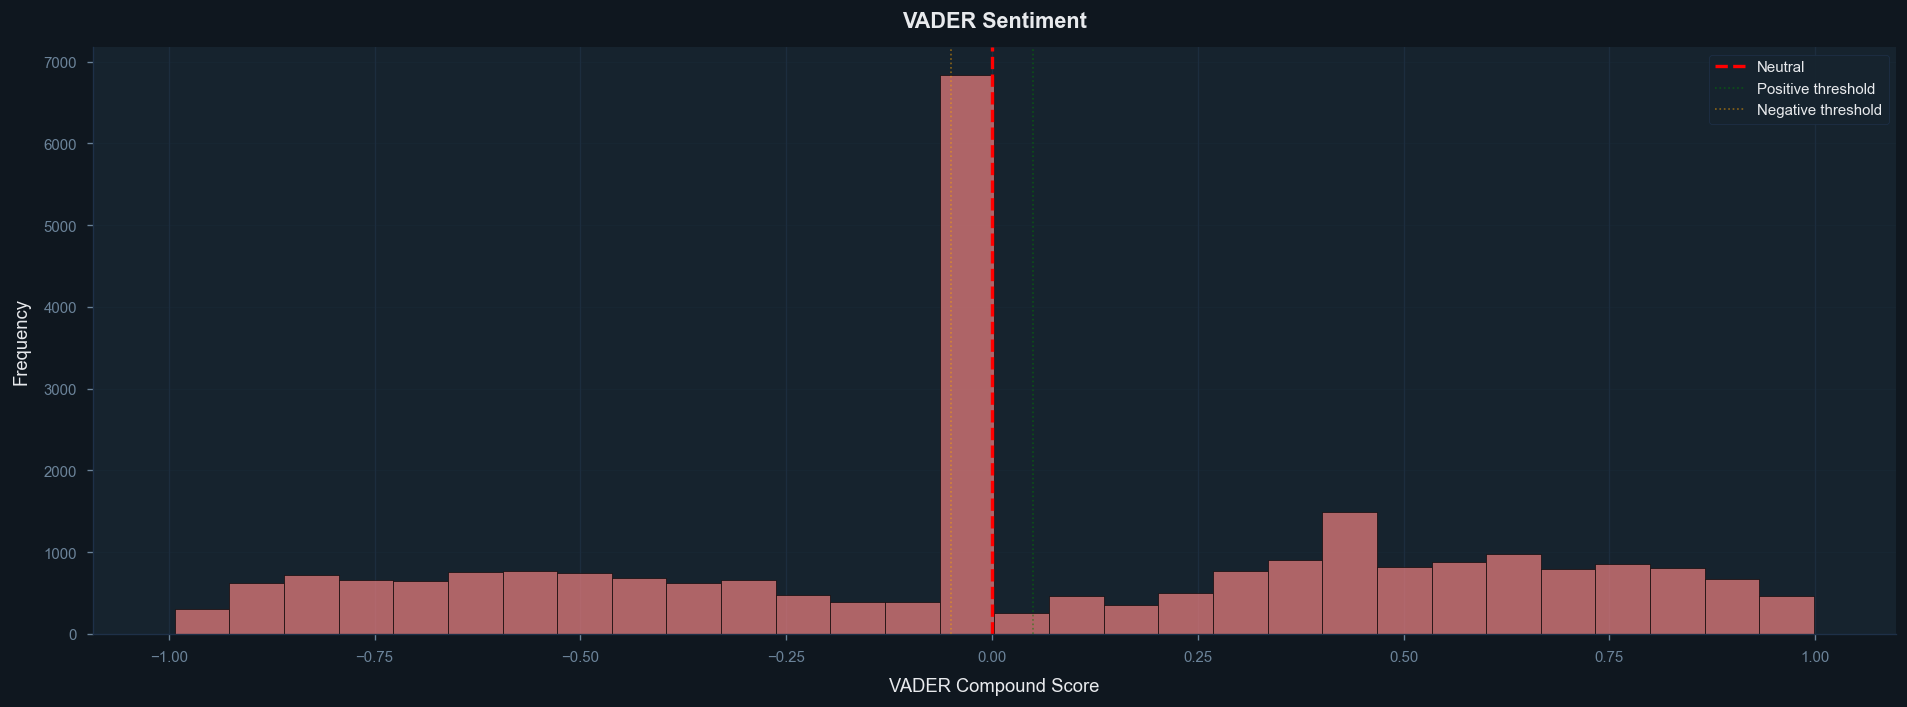

In [11]:
# Create side-by-side comparison
fig, axes = plt.subplots(1,1, figsize=(16, 6))

# VADER distribution
axes.hist(df_clean['vader_compound'], bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
axes.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Neutral')
axes.axvline(x=0.05, color='green', linestyle=':', linewidth=1, alpha=0.5, label='Positive threshold')
axes.axvline(x=-0.05, color='orange', linestyle=':', linewidth=1, alpha=0.5, label='Negative threshold')
axes.set_xlabel('VADER Compound Score')
axes.set_ylabel('Frequency')
axes.set_title('VADER Sentiment')
axes.legend()
axes.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [67]:
df_clean.to_csv("Data/2_Silver/Bluesky/cleaned_data_with_sentiment.csv", index=False)

---
## 2 : TextBlob

In [12]:
from textblob import TextBlob

tb_scores = df_clean['text_norm'].apply(lambda x: TextBlob(str(x)).sentiment)

df_clean['tb_polarity']      = tb_scores.apply(lambda s: s.polarity)
df_clean['tb_subjectivity']  = tb_scores.apply(lambda s: s.subjectivity)

df_clean['tb_label'] = pd.cut(
    df_clean['tb_polarity'],
    bins=[-np.inf, -0.05, 0.05, np.inf],
    labels=['Negative', 'Neutral', 'Positive']
)

print('TextBlob statistics:')
print(df_clean[['tb_polarity','tb_subjectivity']].describe().round(3))
print('\nPolarity distribution:')
print(df_clean['tb_label'].value_counts())

TextBlob statistics:
       tb_polarity  tb_subjectivity
count    26256.000        26256.000
mean         0.061            0.354
std          0.285            0.313
min         -1.000            0.000
25%          0.000            0.000
50%          0.000            0.356
75%          0.200            0.578
max          1.000            1.000

Polarity distribution:
tb_label
Neutral     10988
Positive    10206
Negative     5062
Name: count, dtype: int64


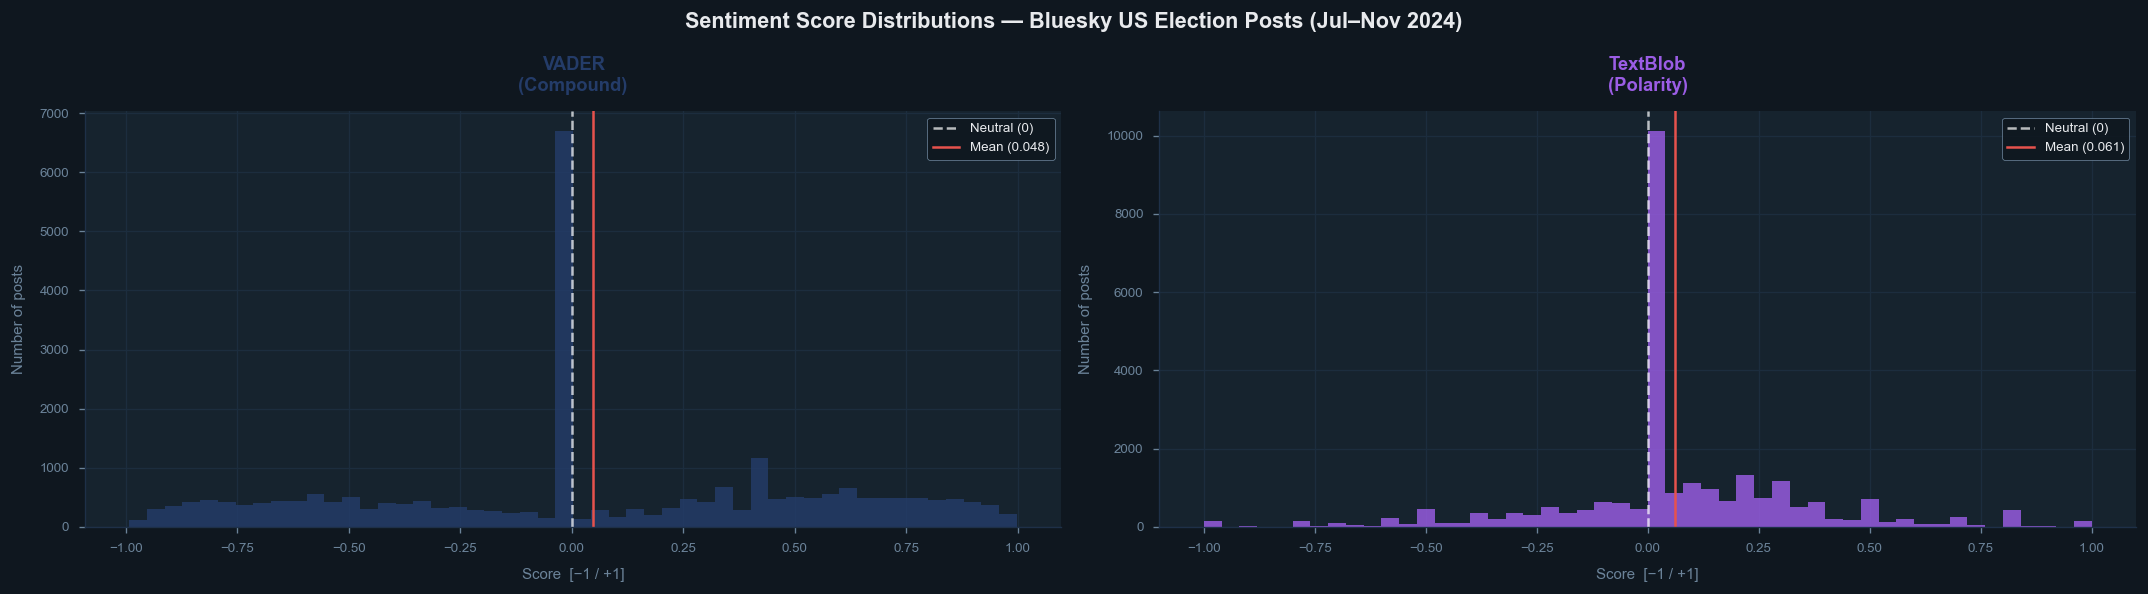

In [15]:
methods = [
    ('vader_compound', 'VADER\n(Compound)',               ACCENT,      '−1 / +1'),
    ('tb_polarity',    'TextBlob\n(Polarity)',            PURPLE,      '−1 / +1'),
]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Sentiment Score Distributions — Bluesky US Election Posts (Jul–Nov 2024)',
             color=TEXT_PRIMARY, fontsize=13, fontweight='bold')

for ax, (col, title, color, scale) in zip(axes, methods):
    ax.set_facecolor(BG_PANEL)
    ax.hist(df_clean[col], bins=50, color=color, alpha=0.82, edgecolor='none')
    ax.axvline(0, color='white', lw=1.5, ls='--', alpha=0.7, label='Neutral (0)')
    mean_val = df_clean[col].mean()
    ax.axvline(mean_val, color=REPUBLICAN, lw=1.5, ls='-',
               label=f'Mean ({mean_val:.3f})')
    ax.set_title(title, color=color, fontsize=11, fontweight='bold')
    ax.set_xlabel(f'Score  [{scale}]', color=TEXT_MUTED, fontsize=9)
    ax.set_ylabel('Number of posts', color=TEXT_MUTED, fontsize=9)
    ax.legend(fontsize=8, facecolor=BG_DARK, edgecolor=TEXT_MUTED, labelcolor=TEXT_PRIMARY)
    ax.tick_params(colors=TEXT_MUTED, labelsize=8)

plt.tight_layout()
plt.show()

## per buzz group polarity 

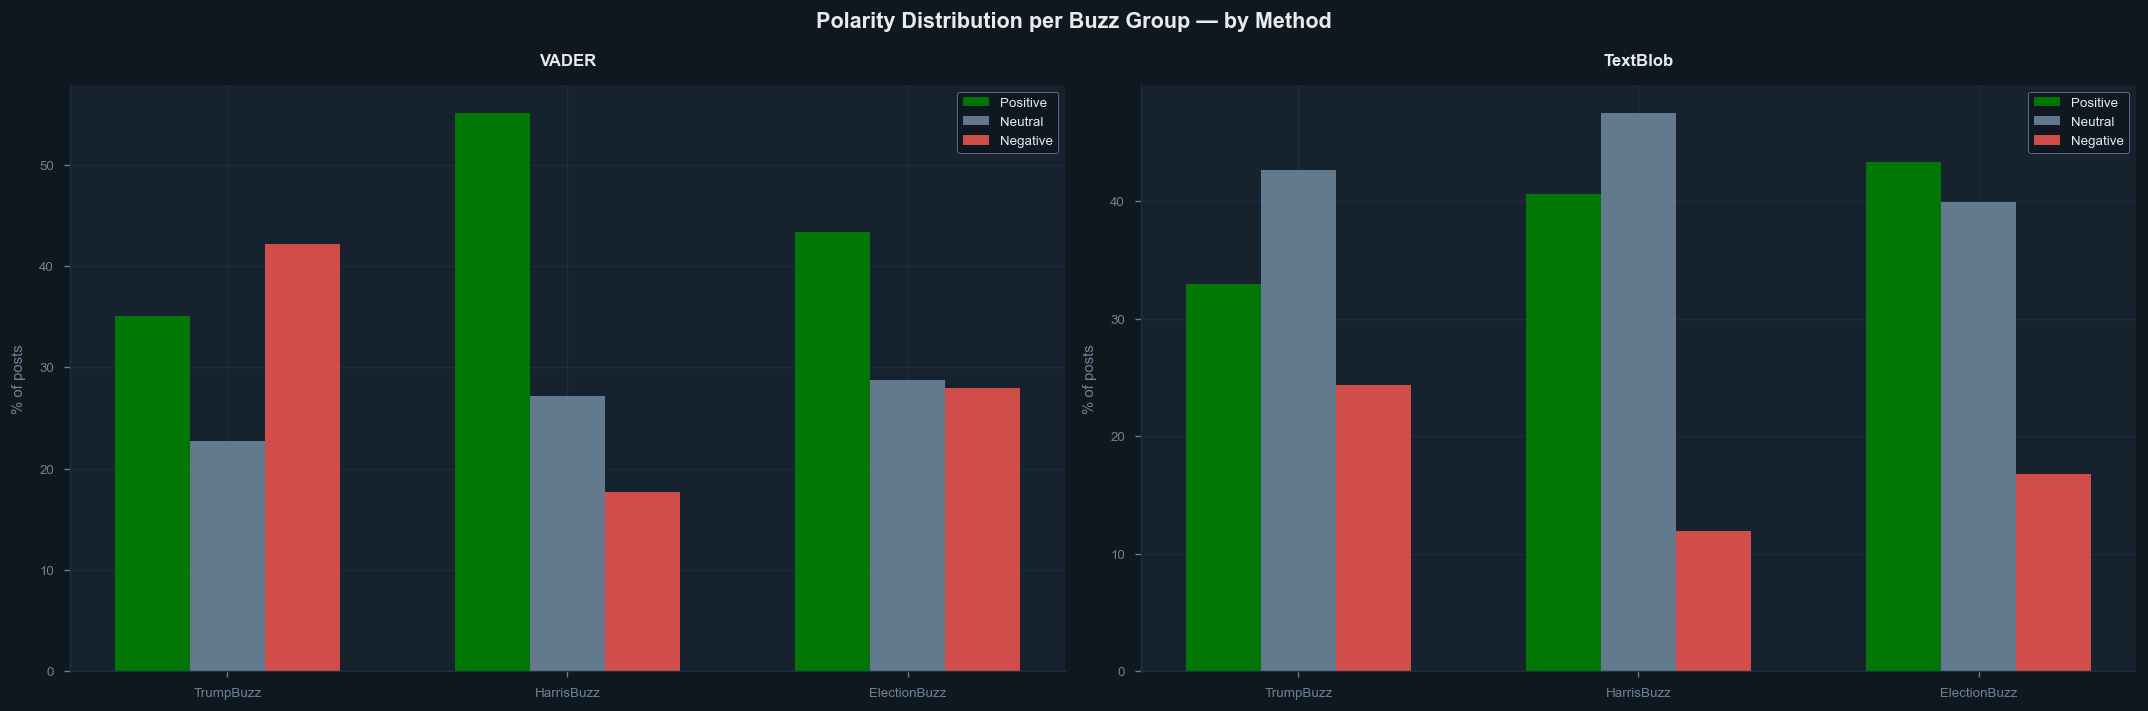

In [19]:
label_methods = [
    ('vader_label', 'VADER',                 ACCENT),
    ('tb_label',    'TextBlob',              PURPLE),
]
buzz_order = ['TrumpBuzz', 'HarrisBuzz', 'ElectionBuzz']
pol_colors  = {'Positive': '#008000', 'Neutral': TEXT_MUTED, 'Negative': REPUBLICAN}

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Polarity Distribution per Buzz Group — by Method',
             color=TEXT_PRIMARY, fontsize=13, fontweight='bold')

for ax, (label_col, title, _) in zip(axes, label_methods):
    ax.set_facecolor(BG_PANEL)

    ct = (
        df_clean.groupby(['buzz_group', label_col])
        .size()
        .unstack(fill_value=0)
        .reindex(buzz_order)
        .apply(lambda r: r / r.sum() * 100, axis=1)
    )

    x      = np.arange(len(buzz_order))
    n_pol  = len(ct.columns)
    w      = 0.22
    offset = np.linspace(-w, w, n_pol)

    for (pol, off) in zip(['Positive', 'Neutral', 'Negative'], offset):
        if pol in ct.columns:
            bars = ax.bar(x + off, ct[pol], width=w,
                          color=pol_colors[pol], alpha=0.9,
                          label=pol, edgecolor='none')

    ax.set_xticks(x)
    ax.set_xticklabels(['TrumpBuzz', 'HarrisBuzz', 'ElectionBuzz'], fontsize=9)
    ax.set_ylabel('% of posts', color=TEXT_MUTED, fontsize=9)
    ax.set_title(title, color=TEXT_PRIMARY, fontsize=10, fontweight='bold')
    ax.tick_params(colors=TEXT_MUTED, labelsize=8)
    ax.legend(fontsize=8, facecolor=BG_DARK, edgecolor=TEXT_MUTED, labelcolor=TEXT_PRIMARY)

plt.tight_layout()
plt.savefig('sent_buzz_breakdown.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()

# sentiment over time

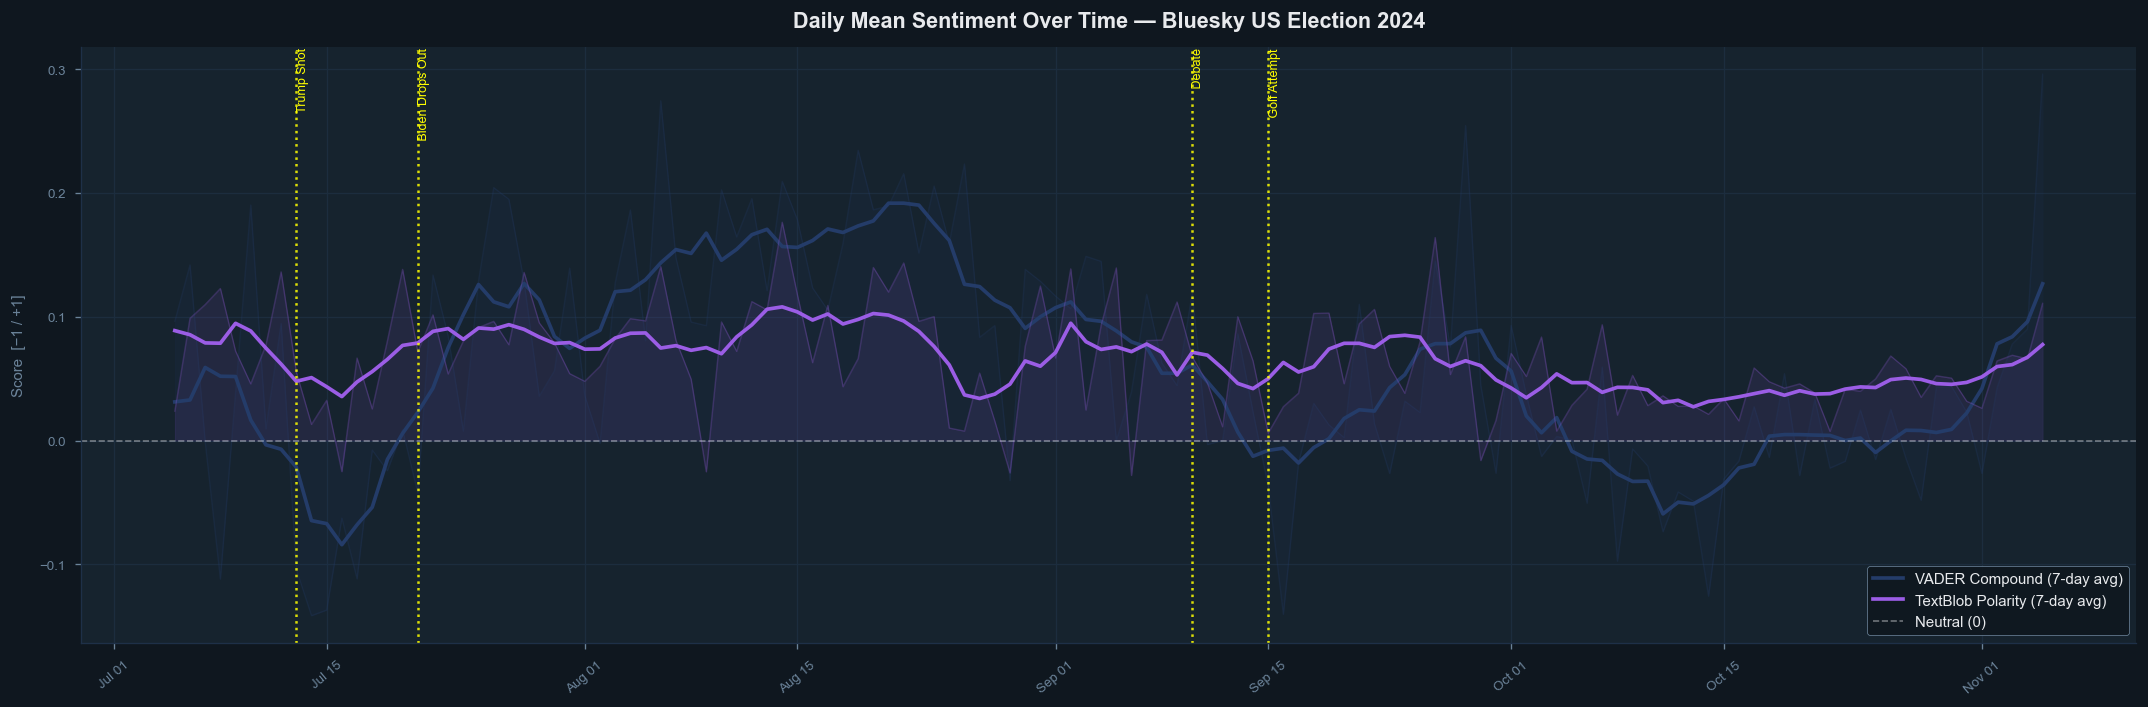

In [25]:
# Compute daily means per method
daily = (
    df_clean.groupby('date')[['vader_compound', 'tb_polarity']]
    .mean()
    .sort_index()
)

configs = [
    ('vader_compound', 'VADER Compound',    ACCENT),
    ('tb_polarity',    'TextBlob Polarity', PURPLE),
]

fig, ax = plt.subplots(figsize=(18, 6))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

for col, label, color in configs:
    smooth = daily[col].rolling(7, center=True, min_periods=3).mean()
    ax.fill_between(daily.index, daily[col], alpha=0.10, color=color)
    ax.plot(daily.index, daily[col], color=color, alpha=0.25, lw=0.8)
    ax.plot(daily.index, smooth, color=color, lw=2.2, label=f'{label} (7-day avg)')

ax.axhline(0, color='white', lw=1, ls='--', alpha=0.4, label='Neutral (0)')

for ev in EVENTS:
    ax.axvline(ev['date'], color='#FFFF00', lw=1.5, ls=':', alpha=0.85)
    ax.text(ev['date'], ax.get_ylim()[1], f" {ev['label']}",
            color='#FFFF00', fontsize=7.5, va='top', rotation=90)

ax.set_title('Daily Mean Sentiment Over Time — Bluesky US Election 2024',
             color=TEXT_PRIMARY, fontsize=13, fontweight='bold')
ax.set_ylabel('Score  [−1 / +1]', color=TEXT_MUTED, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.tick_params(axis='x', rotation=40, colors=TEXT_MUTED, labelsize=8)
ax.tick_params(axis='y', colors=TEXT_MUTED, labelsize=8)
ax.legend(fontsize=9, facecolor=BG_DARK, edgecolor=TEXT_MUTED, labelcolor=TEXT_PRIMARY,
          loc='lower right')

plt.tight_layout()
plt.savefig('sent_over_time.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()

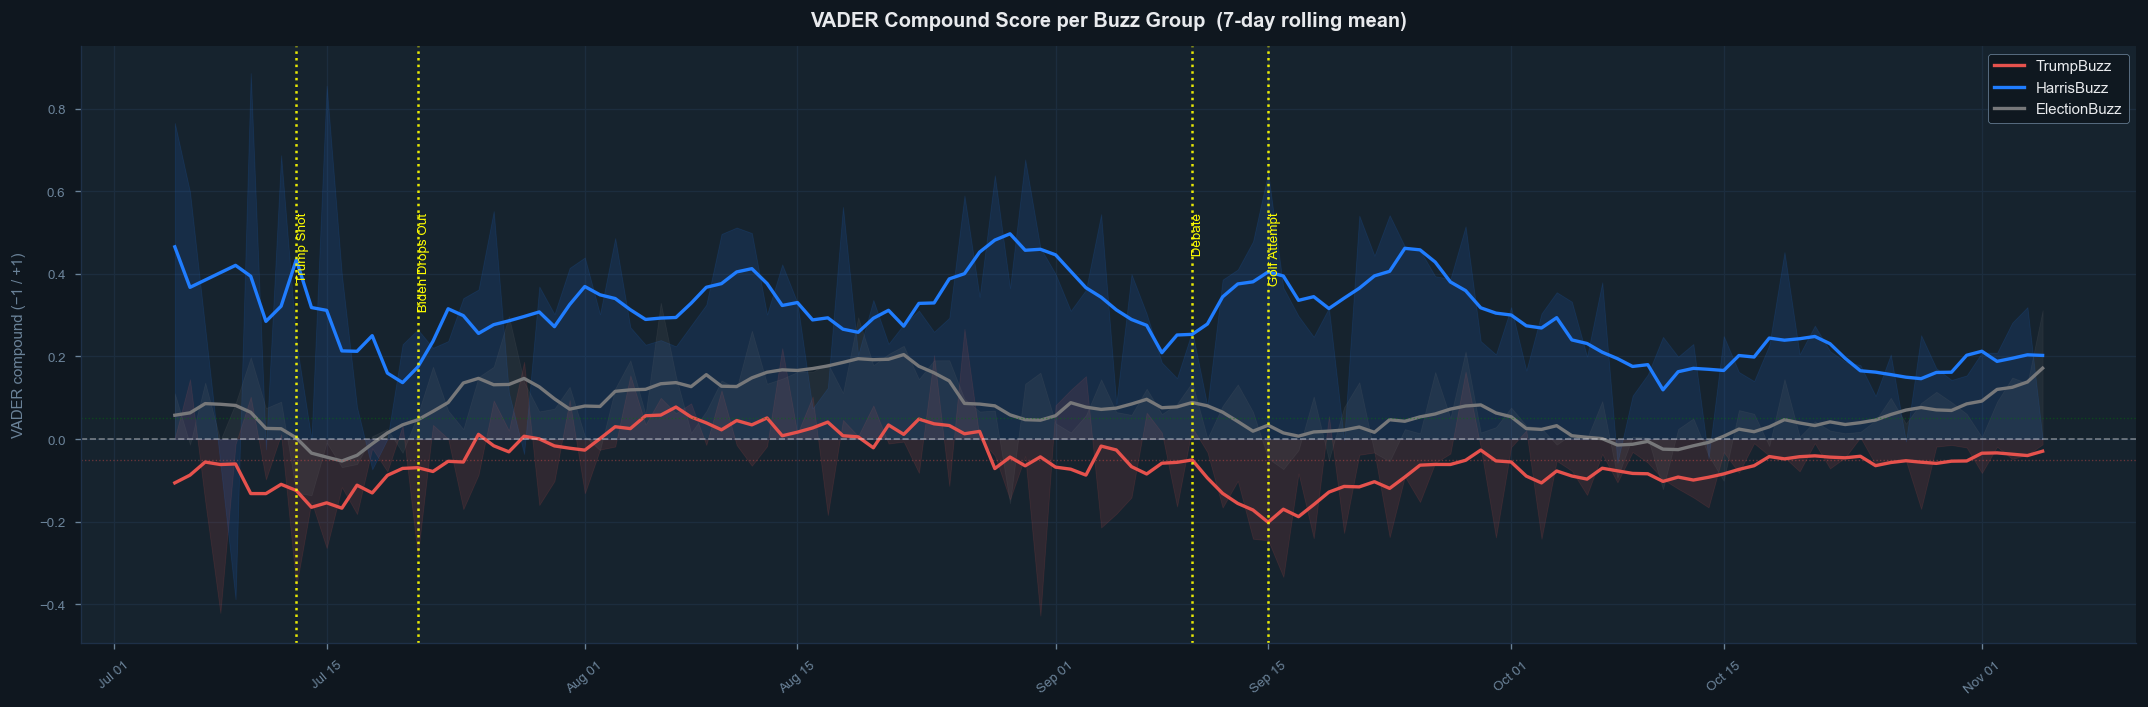

In [26]:
fig, ax = plt.subplots(figsize=(18, 6))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

for group, color in BUZZ_COLORS.items():
    sub = df_clean[df_clean['buzz_group'] == group]
    daily_g = sub.groupby('date')['vader_compound'].mean().sort_index()
    smooth  = daily_g.rolling(7, center=True, min_periods=3).mean()
    ax.fill_between(daily_g.index, daily_g, alpha=0.12, color=color)
    ax.plot(daily_g.index, smooth, color=color, lw=2, label=group)

ax.axhline(0,    color='white', lw=1, ls='--', alpha=0.4)
ax.axhline(0.05, color='#008000',   lw=0.8, ls=':', alpha=0.4)
ax.axhline(-0.05,color=REPUBLICAN, lw=0.8, ls=':', alpha=0.4)

for ev in EVENTS:
    ax.axvline(ev['date'], color='#FFFF00', lw=1.5, ls=':', alpha=0.9)
    ax.text(ev['date'], 0.55, f" {ev['label']}",
            color='#FFFF00', fontsize=8, va='top', rotation=90)

ax.set_title('VADER Compound Score per Buzz Group  (7-day rolling mean)',
             color=TEXT_PRIMARY, fontsize=12, fontweight='bold')
ax.set_ylabel('VADER compound (−1 / +1)', color=TEXT_MUTED, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.tick_params(axis='x', rotation=40, colors=TEXT_MUTED, labelsize=8)
ax.tick_params(axis='y', colors=TEXT_MUTED, labelsize=8)
ax.legend(fontsize=9, facecolor=BG_DARK, edgecolor=TEXT_MUTED, labelcolor=TEXT_PRIMARY)

plt.tight_layout()
plt.savefig('sent_vader_buzz_time.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()

There are two levels of averaging happening:

    Per day — all posts on that day get their VADER score averaged into a single daily mean

    Rolling — that daily mean then gets smoothed again over a 7-day window


---
## 3 : NRCLex: Emotion Detection

In [58]:
from nrclex import NRCLex

def analyze_emotions_nrclex(text):
    emotion = NRCLex(text)
    affect  = emotion.affect_frequencies
    return {
        'fear':         affect.get('fear', 0),
        'anger':        affect.get('anger', 0),
        'anticipation': affect.get('anticipation', 0),
        'trust':        affect.get('trust', 0),
        'surprise':     affect.get('surprise', 0),
        'nrc_positive': affect.get('positive', 0),
        'nrc_negative': affect.get('negative', 0),
        'sadness':      affect.get('sadness', 0),
        'disgust':      affect.get('disgust', 0),
        'joy':          affect.get('joy', 0)
    }

print("Analyzing emotions with NRCLex...")
emotion_results   = df_clean['text'].apply(analyze_emotions_nrclex)
emotion_df        = pd.DataFrame(emotion_results.tolist())
df_clean_emotions = pd.concat([df_clean.reset_index(drop=True),
                                emotion_df.reset_index(drop=True)], axis=1)
df_clean_emotions = df_clean_emotions.loc[:, ~df_clean_emotions.columns.duplicated()]

print("✓ Emotion analysis complete!")
df_clean_emotions.head()

Analyzing emotions with NRCLex...
✓ Emotion analysis complete!


,text,timestamp,likes,reposts,replies,mentions,is_reply,post_type,date,hour,...,fear,anger,anticipation,trust,surprise,nrc_positive,nrc_negative,sadness,disgust,joy
0,Canadian election prediction: Americans will g...,2024-11-04 23:44:15.319000+00:00,0,0,1,[],False,post,2024-11-04,23,...,0.052632,0.157895,0.052632,0.105263,0.000000,0.210526,0.263158,0.000000,0.157895,0.000000
1,Why are swinger states so important in the ? ...,2024-11-04 23:35:21.961000+00:00,0,0,0,[],False,post,2024-11-04,23,...,0.000000,0.000000,0.166667,0.333333,0.000000,0.333333,0.000000,0.000000,0.000000,0.166667
2,If Joe Biden winning felt like Return of the J...,2024-11-04 23:23:51.647000+00:00,0,0,0,[],False,post,2024-11-04,23,...,0.083333,0.000000,0.166667,0.166667,0.083333,0.166667,0.000000,0.083333,0.083333,0.166667
3,Will the U.S. Presidential Elections be a Turn...,2024-11-04 22:48:56.805000+00:00,3,1,1,[],False,post,2024-11-04,22,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,Dear American voters! As a foreigner living in...,2024-11-04 22:10:36.540000+00:00,0,0,1,[],False,post,2024-11-04,22,...,0.166667,0.166667,0.000000,0.000000,0.000000,0.166667,0.166667,0.166667,0.166667,0.000000


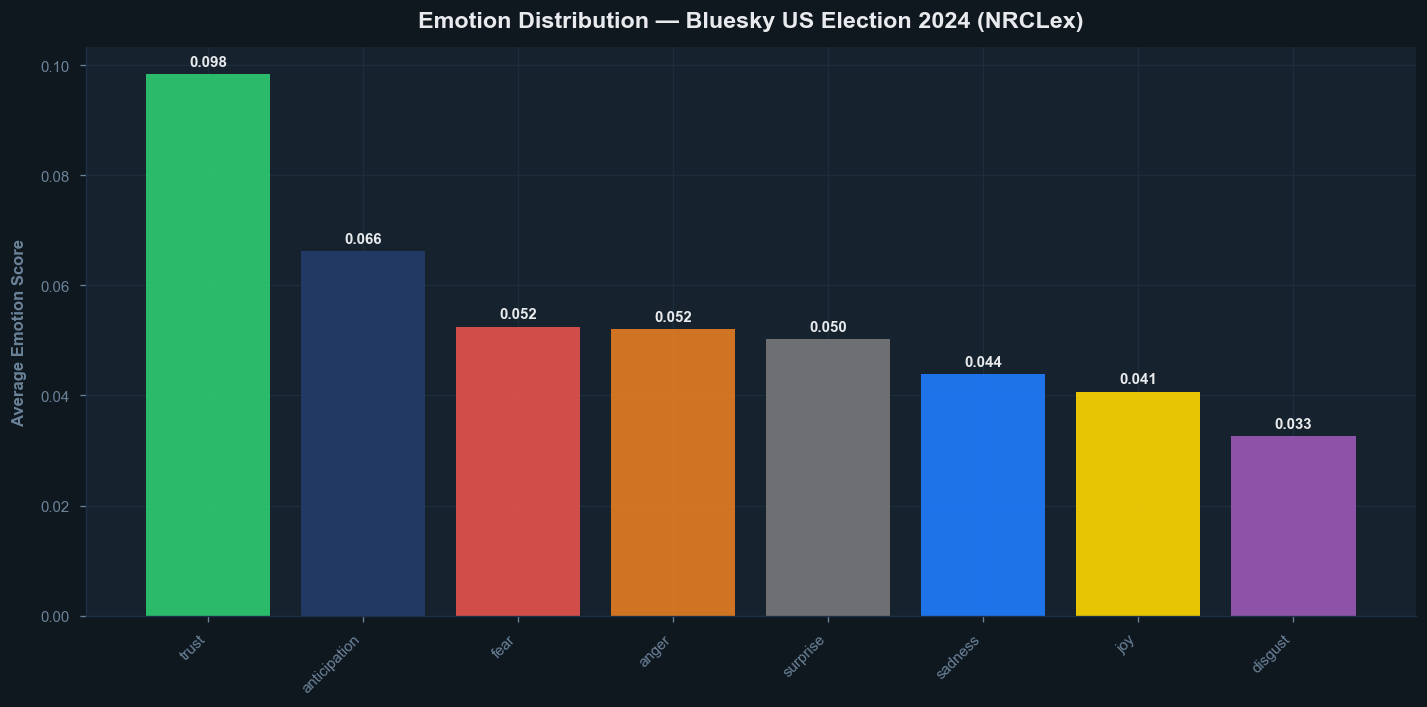

In [59]:
from house_style import *
apply_style()

emotion_cols = ['fear', 'anger', 'anticipation', 'trust', 'surprise', 'sadness', 'disgust', 'joy']

# Take only the first occurrence of each emotion column to avoid duplicates
avg_emotions = df_clean_emotions[emotion_cols].loc[:, ~df_clean_emotions[emotion_cols].columns.duplicated()].mean().sort_values(ascending=False)

EMOTION_COLORS = {
    'fear': REPUBLICAN, 'anger': '#e67e22', 'anticipation': ACCENT,
    'trust': '#2ecc71',     'surprise': NEUTRAL, 'sadness': DEMOCRAT,
    'disgust': '#9b59b6', 'joy': '#FFD700'
}

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

bars = ax.bar(range(len(avg_emotions)), avg_emotions.values,
              color=[EMOTION_COLORS[e] for e in avg_emotions.index],
              edgecolor='none', alpha=0.9)

ax.set_xticks(range(len(avg_emotions)))
ax.set_xticklabels(avg_emotions.index, rotation=45, ha='right', color=TEXT_PRIMARY)
ax.set_ylabel('Average Emotion Score', color=TEXT_MUTED, fontsize=10, fontweight='bold')
ax.set_title('Emotion Distribution — Bluesky US Election 2024 (NRCLex)',
             color=TEXT_PRIMARY, fontsize=14, fontweight='bold')
ax.tick_params(colors=TEXT_MUTED)

for bar, value in zip(bars, avg_emotions.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.001, f'{value:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold', color=TEXT_PRIMARY)

plt.tight_layout()
plt.show()

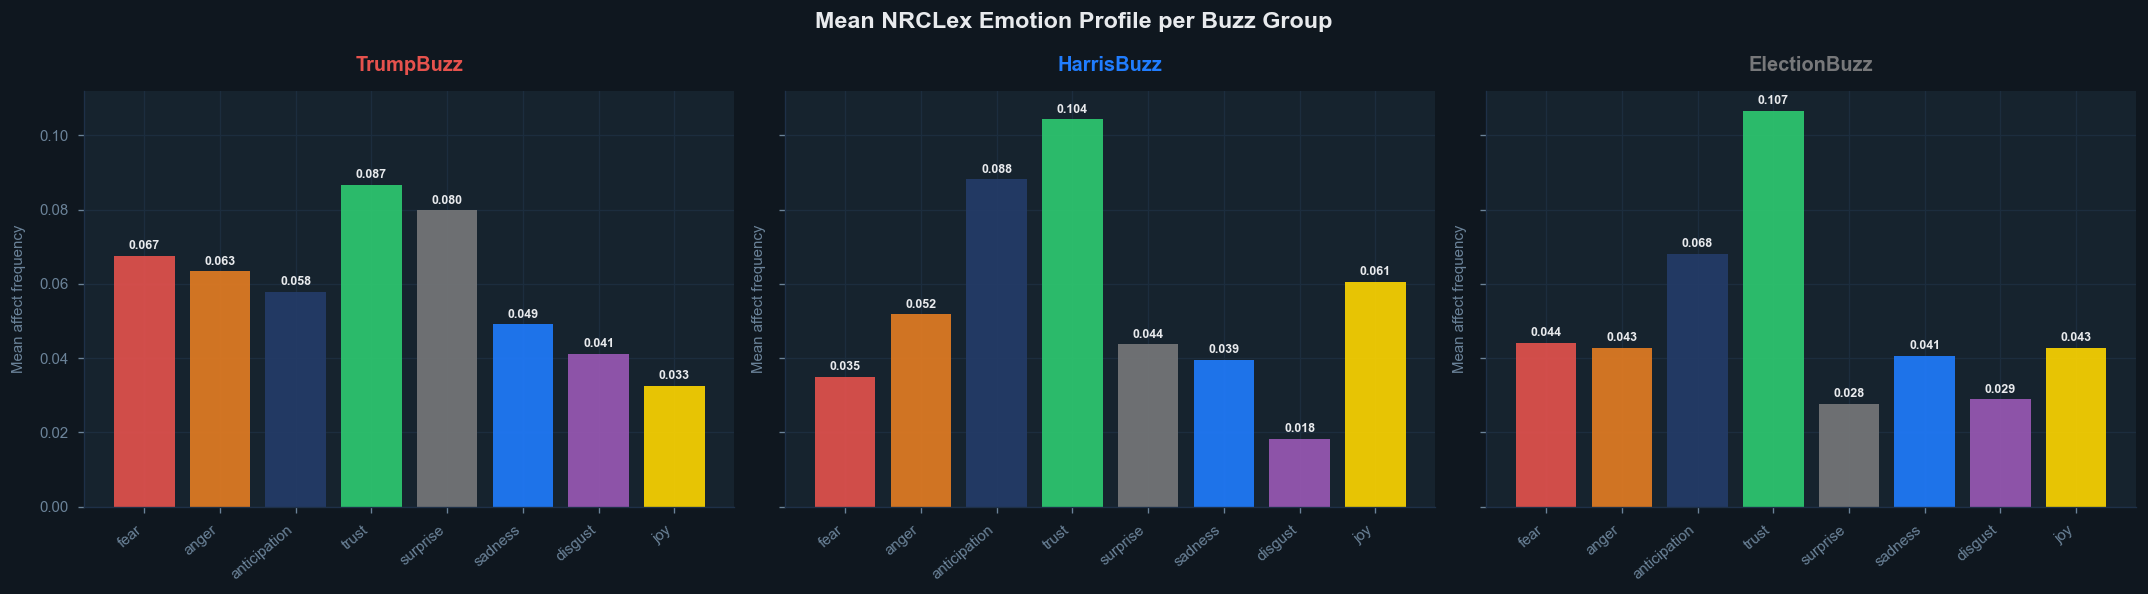

In [60]:
from house_style import *
apply_style()

emotion_cols = ['fear', 'anger', 'anticipation', 'trust', 'surprise', 'sadness', 'disgust', 'joy']

EMOTION_COLORS = {
    'fear': REPUBLICAN, 'anger': '#e67e22', 'anticipation': ACCENT,
    'trust': '#2ecc71', 'surprise': NEUTRAL, 'sadness': DEMOCRAT,
    'disgust': '#9b59b6', 'joy': '#FFD700'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Mean NRCLex Emotion Profile per Buzz Group',
             color=TEXT_PRIMARY, fontsize=14, fontweight='bold')

for ax, (group, buzz_color) in zip(axes, BUZZ_COLORS.items()):
    sub    = df_clean_emotions[df_clean_emotions['buzz_group'] == group]
    means  = sub[emotion_cols].loc[:, ~sub[emotion_cols].columns.duplicated()].mean()

    bars = ax.bar(emotion_cols, means.values,
                  color=[EMOTION_COLORS[e] for e in emotion_cols],
                  edgecolor='none', alpha=0.9)

    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.001,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=7.5, fontweight='bold', color=TEXT_PRIMARY)

    ax.set_facecolor(BG_PANEL)
    ax.set_title(group, fontsize=12, fontweight='bold', color=buzz_color)
    ax.set_xticks(range(len(emotion_cols)))
    ax.set_xticklabels(emotion_cols, rotation=40, ha='right',
                       fontsize=9, color=TEXT_PRIMARY)
    ax.set_ylabel('Mean affect frequency', color=TEXT_MUTED, fontsize=9)
    ax.tick_params(colors=TEXT_MUTED)

plt.tight_layout()
plt.savefig('nrc_emotion_buzz_profile.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()


Correlation matrix:
                  vader_compound  tb_polarity  nrclex_sentiment
vader_compound          1.000000     0.418650          0.284881
tb_polarity             0.418650     1.000000          0.231012
nrclex_sentiment        0.284881     0.231012          1.000000


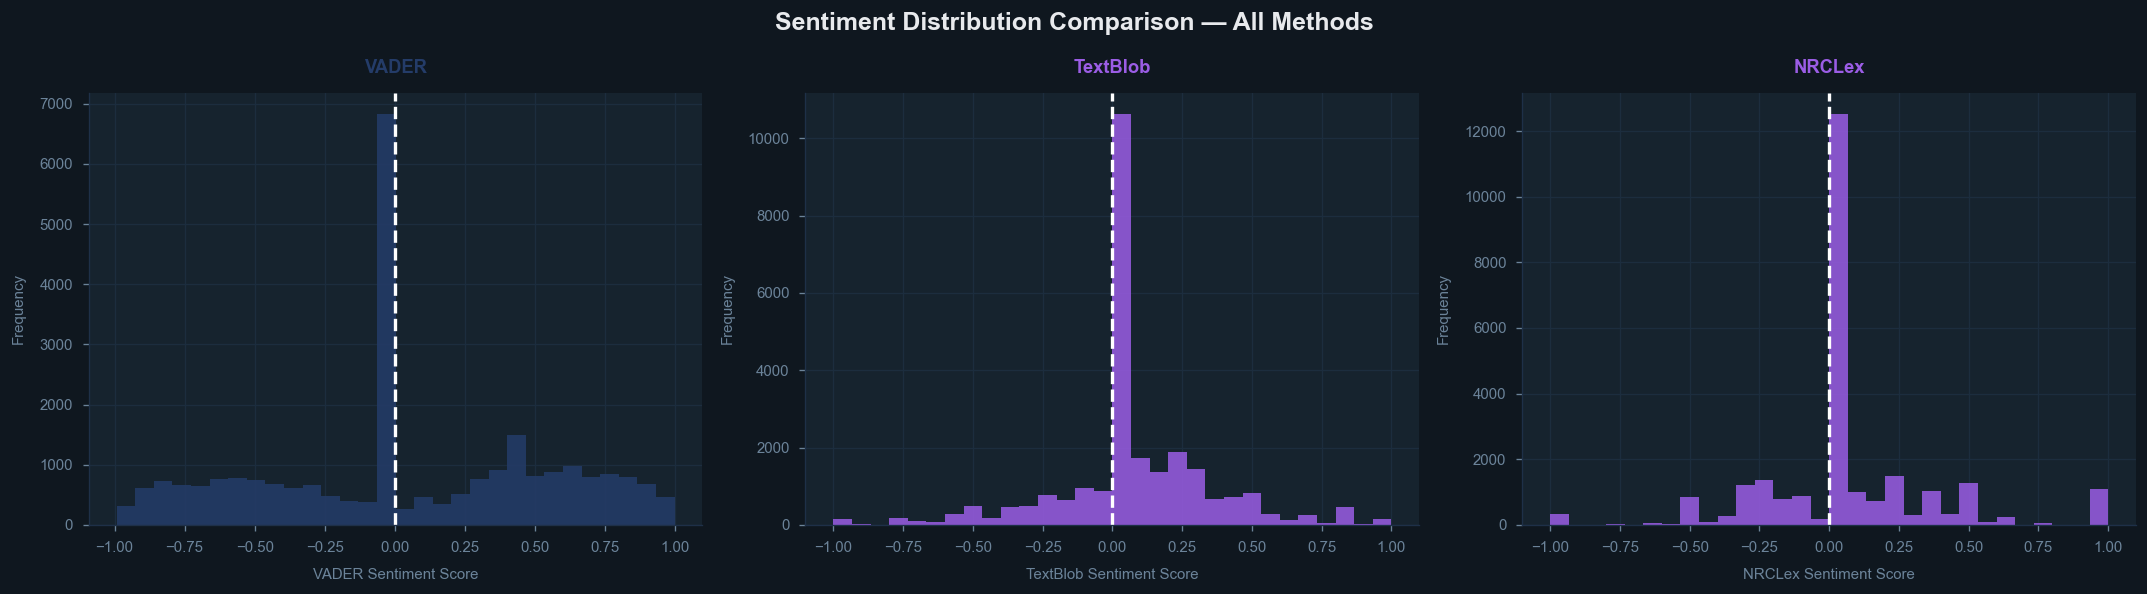

In [61]:
# Deduplicate columns first
df_clean_emotions = df_clean_emotions.loc[:, ~df_clean_emotions.columns.duplicated()]

# NRCLex net sentiment + correlation with other methods
df_clean_emotions['nrclex_sentiment'] = (
    df_clean_emotions['nrc_positive'] - df_clean_emotions['nrc_negative']
)

sentiment_methods = ['vader_compound', 'tb_polarity', 'nrclex_sentiment']
correlation_matrix = df_clean_emotions[sentiment_methods].corr()

print("\nCorrelation matrix:")
print(correlation_matrix)

methods = [
    ('vader_compound',   'VADER',    ACCENT),
    ('tb_polarity',      'TextBlob', '#9b5de5'),
    ('nrclex_sentiment', 'NRCLex',   PURPLE),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(BG_DARK)

for (col, name, color), ax in zip(methods, axes):
    ax.set_facecolor(BG_PANEL)
    ax.hist(df_clean_emotions[col], bins=30, color=color, edgecolor='none', alpha=0.85)
    ax.axvline(x=0, color='white', linestyle='--', linewidth=2)
    ax.set_xlabel(f'{name} Sentiment Score', color=TEXT_MUTED, fontsize=9)
    ax.set_ylabel('Frequency', color=TEXT_MUTED, fontsize=9)
    ax.set_title(name, color=color, fontsize=11, fontweight='bold')
    ax.tick_params(colors=TEXT_MUTED)

fig.suptitle('Sentiment Distribution Comparison — All Methods',
             color=TEXT_PRIMARY, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

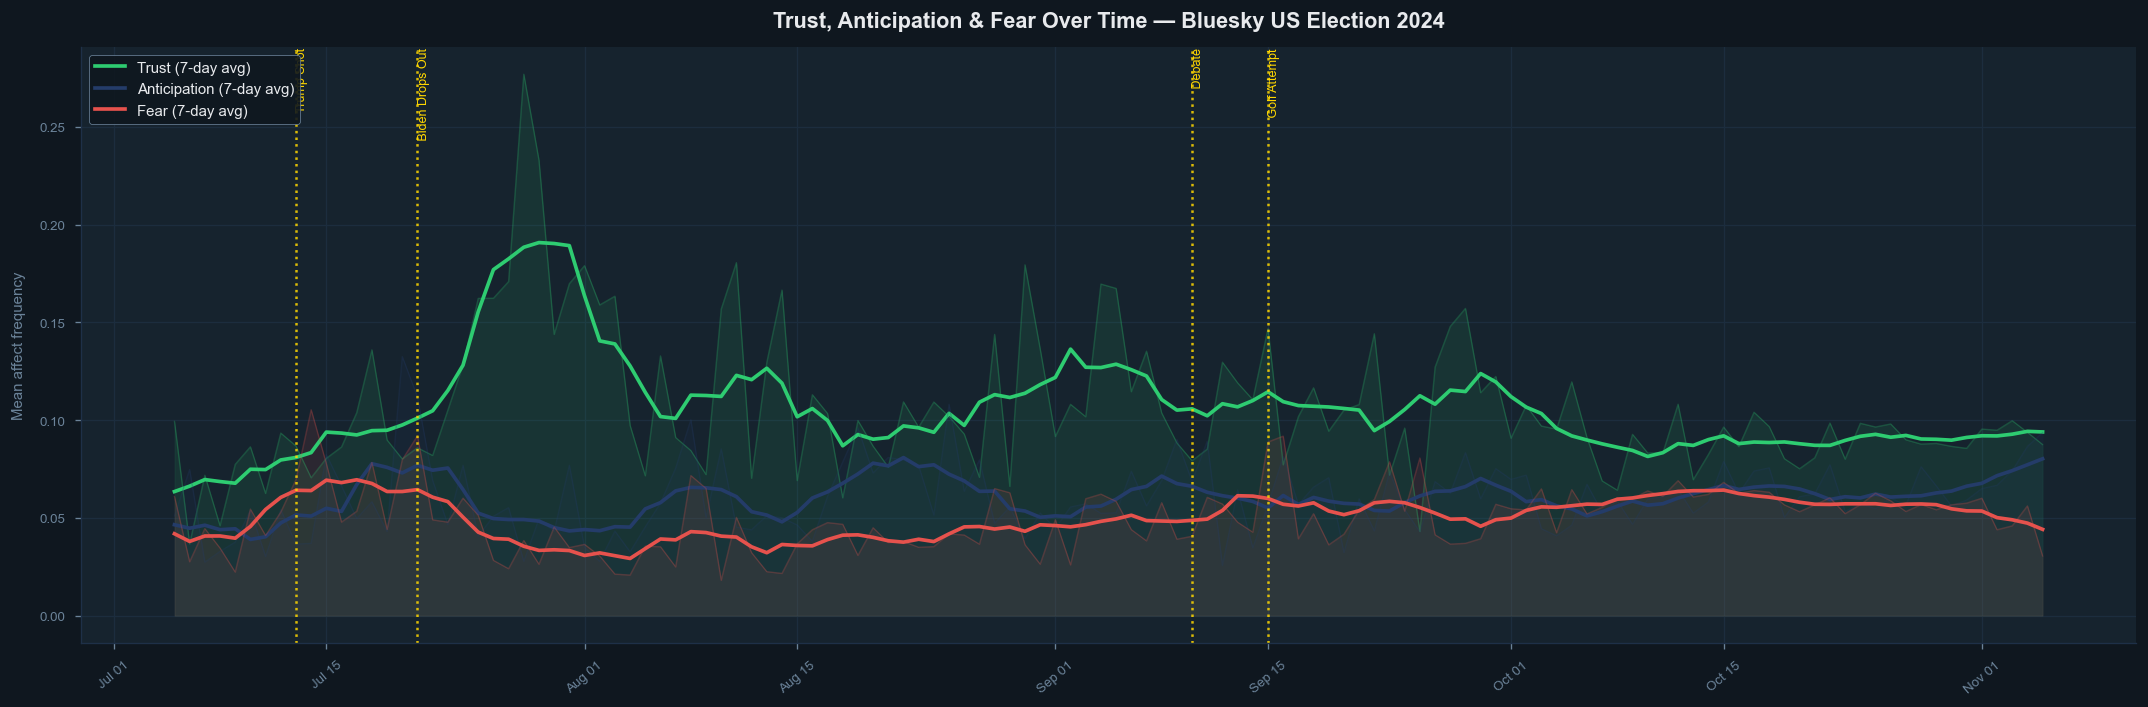

In [64]:
emotions_time = ['trust', 'anticipation', 'fear']
emotion_colors_time = {'trust': '#2ecc71', 'anticipation': ACCENT, 'fear': REPUBLICAN}

fig, ax = plt.subplots(figsize=(18, 6))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

for emotion in emotions_time:
    daily = df_clean_emotions.groupby('date')[emotion].mean().sort_index()
    smooth = daily.rolling(7, center=True, min_periods=3).mean()
    ax.fill_between(daily.index, daily, alpha=0.10, color=emotion_colors_time[emotion])
    ax.plot(daily.index, daily, color=emotion_colors_time[emotion], alpha=0.25, lw=0.8)
    ax.plot(daily.index, smooth, color=emotion_colors_time[emotion], lw=2.2,
            label=f'{emotion.capitalize()} (7-day avg)')

for ev in EVENTS:
    ax.axvline(ev['date'], color='#FFD700', lw=1.5, ls=':', alpha=0.85)
    ax.text(ev['date'], ax.get_ylim()[1], f" {ev['label']}",
            color='#FFD700', fontsize=7.5, va='top', rotation=90)

ax.set_title('Trust, Anticipation & Fear Over Time — Bluesky US Election 2024',
             color=TEXT_PRIMARY, fontsize=13, fontweight='bold')
ax.set_ylabel('Mean affect frequency', color=TEXT_MUTED, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.tick_params(axis='x', rotation=40, colors=TEXT_MUTED, labelsize=8)
ax.tick_params(axis='y', colors=TEXT_MUTED, labelsize=8)
ax.legend(fontsize=9, facecolor=BG_DARK, edgecolor=TEXT_MUTED, labelcolor=TEXT_PRIMARY,
          loc='upper left')

plt.tight_layout()
plt.show()